# Superstore sales dataset

## Task 1: Data loading,merging and deep exploration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [15]:
df= pd.read_csv("train.csv",parse_dates=["Order Date","Ship Date"],
            encoding="latin1"
           )
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [10]:
print("MIssing values",df.isnull().sum())

MIssing values Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


In [9]:
df=df.dropna()

In [11]:
print("Duplicate values:",df.duplicated().sum())

Duplicate values: 0


In [12]:
print("data type issues:",df.dtypes)

data type issues: Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9789 non-null   int64  
 1   Order ID       9789 non-null   object 
 2   Order Date     9789 non-null   object 
 3   Ship Date      9789 non-null   object 
 4   Ship Mode      9789 non-null   object 
 5   Customer ID    9789 non-null   object 
 6   Customer Name  9789 non-null   object 
 7   Segment        9789 non-null   object 
 8   Country        9789 non-null   object 
 9   City           9789 non-null   object 
 10  State          9789 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9789 non-null   object 
 13  Product ID     9789 non-null   object 
 14  Category       9789 non-null   object 
 15  Sub-Category   9789 non-null   object 
 16  Product Name   9789 non-null   object 
 17  Sales          9789 non-null   float64
dtypes: float64(2)

In [10]:

df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9789 non-null   int64         
 1   Order ID       9789 non-null   object        
 2   Order Date     9789 non-null   datetime64[ns]
 3   Ship Date      9789 non-null   datetime64[ns]
 4   Ship Mode      9789 non-null   object        
 5   Customer ID    9789 non-null   object        
 6   Customer Name  9789 non-null   object        
 7   Segment        9789 non-null   object        
 8   Country        9789 non-null   object        
 9   City           9789 non-null   object        
 10  State          9789 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9789 non-null   object        
 13  Product ID     9789 non-null   object        
 14  Category       9789 non-null   object        
 15  Sub-Category   9789 non-nu

In [11]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()

df["Week Number"] = df["Order Date"].dt.isocalendar().week

df["Day of Week"] = df["Order Date"].dt.day_name()

df["Quarter"] = df["Order Date"].dt.quarter


In [14]:
def get_season(month):
    if month in[12,1,2]:
        return "winter"
    elif month in [3,4,5]:
        return "spring"
    else:
        return "Autumn"
df["Season"]=df["Month"].apply(get_season)       

In [15]:
df["Shipping Days"]=(df["Ship Date"]-df["Order Date"]).dt.days

In [17]:
weekly_sales=(df.groupby(pd.Grouper(key="Order Date",freq="W"))["Sales"].sum())
print(weekly_sales.head())

Order Date
2015-01-04     304.508
2015-01-11    4619.108
2015-01-18    4130.533
2015-01-25    3092.544
2015-02-01    2527.914
Freq: W-SUN, Name: Sales, dtype: float64


monthly_sales=(df.groupby(pd.Grouper(key="Order Date",freq="M"))["Sales"].sum())
print(monthly_sales.head())

### Question 1

### Which product category generates the highest revenue?

In [19]:
category_sales=df.groupby("Category")["Sales"].sum()
print(category_sales)
print("\nHighest revenue category")
print(category_sales.idxmax())

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64

Highest revenue category
Technology


### Question 2

### Region with most consistent sales growth

In [22]:

region_year_sales=df.pivot_table( values="Sales",index="Year",columns="Region",aggfunc="sum")
print(region_year_sales)

Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255


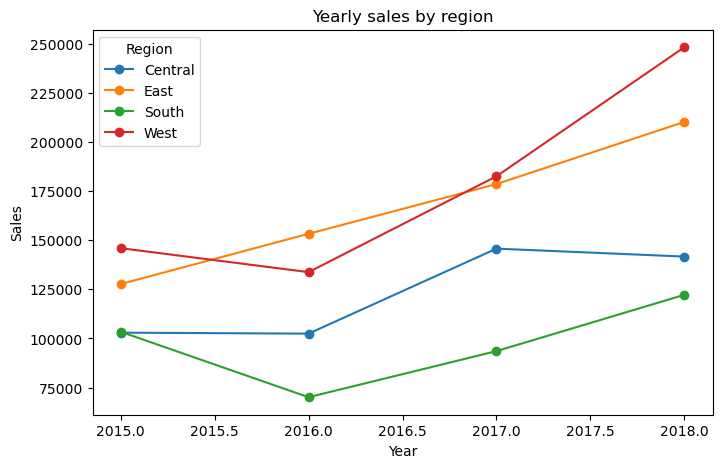

In [23]:
import matplotlib.pyplot as plt  # Import matplotlib.pyplot to use plt functions

region_year_sales.plot(marker='o',figsize=(8,5))
plt.title("Yearly sales by region")
plt.ylabel("Sales")
plt.show()

## Question 3

### Average Shipping Time by region

In [8]:
import pandas as pd
df= pd.read_csv("train.csv",parse_dates=["Order Date","Ship Date"],
            encoding="latin1"
           )
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")
df["Ship Days"]=(df["Ship Date"]-df["Order Date"]).dt.days
shipping_region=df.groupby("Region")["Ship Days"].mean()
print(shipping_region)

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Ship Days, dtype: float64


### Question 4

### Monthly seasonality

In [10]:
df["Month Name"]=df["Order Date"].dt.month_name()
monthly_pattern=df.groupby("Month Name")["Sales"].mean()
month_order=["January","February","March","April","May","June","July","August","September","October","November","December"]
monthly_pattern=monthly_pattern.reindex(month_order)
print(monthly_pattern)

Month Name
January      257.627403
February     199.902745
March        290.549393
April        207.432269
May          212.533412
June         211.052856
July         208.802997
August       227.007110
September    221.642106
October      246.596162
November     241.657496
December     232.619515
Name: Sales, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

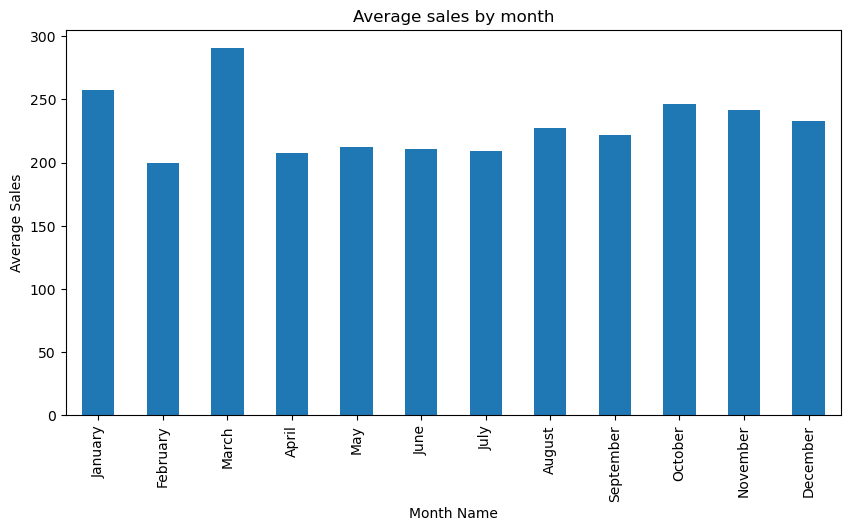

In [12]:
import matplotlib.pyplot as plt
monthly_pattern.plot(kind="bar",figsize=(10,5))
plt.title("Average sales by month")
plt.ylabel("Average Sales")
plt.show

## Task 2 : Time Series Analysis

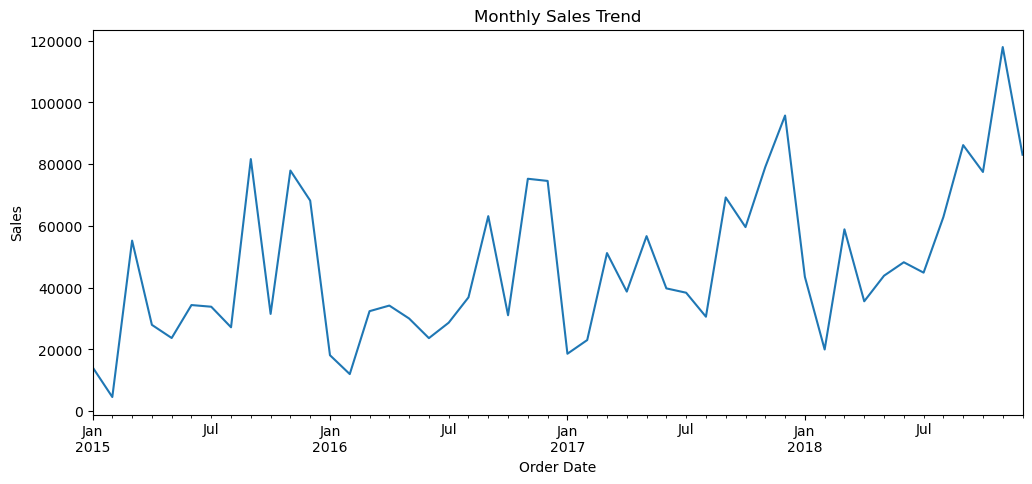

In [15]:
monthly_sales=(df.groupby(pd.Grouper(key="Order Date",freq="ME"))["Sales"].sum()) 
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.ylabel("Sales")

plt.show()

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

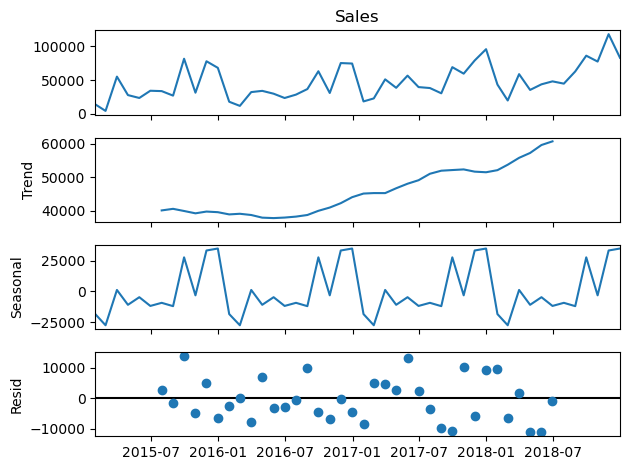

In [18]:
decomposition.plot()
plt.show()

In [19]:
trend =decomposition.trend

In [20]:
seasonal=decomposition.seasonal

In [21]:
residual=decomposition.resid

### ADF Test

In [23]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(monthly_sales.dropna())

print("ADF Statistic:", result[0])

print("p-value:", result[1])

print("Critical Values:")

for key, value in result[4].items():
    print(key, value)

ADF Statistic: -4.41613676143077
p-value: 0.00027791039276670493
Critical Values:
1% -3.5778480370438146
5% -2.925338105429433
10% -2.6007735310095064


In [24]:
monthly_diff=monthly_sales.diff().dropna()

### Re-Test

In [25]:
result2=adfuller(monthly_diff)

In [26]:
print("ADF Statistics",result2[0])
print("p-value:",result2[1])
      

ADF Statistics -8.727061830353271
p-value: 3.266917547279569e-14


## OBSERVATIONS

### The monthly sales trend shows whether overall sales increase, decrease, or remain stable over the four years.
### The seasonal component indicates recurring monthly patterns. Larger fluctuations mean stronger seasonality.
### Large spikes in the residual component represent unusual events or outliers not explained by the trend or seasonality.
### A stationary series has constant statistical properties (such as mean and variance) over time. 
### If the ADF test p-value is less than 0.05, the series is stationary; if it is greater than 0.05, it is non-stationary and differencing is typically applied before modeling.

## Task 3: Sales forecasting using three differrent models

### Model 1: SARIMA Model

In [5]:
!pip install prophet

  Using cached prophet-1.3.0-py3-none-win_amd64.whl.metadata (3.6 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached holidays-0.100-py3-none-any.whl.metadata (53 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached prophet-1.3.0-py3-none-win_amd64.whl (12.1 MB)
Using cached holidays-0.100-py3-none-any.whl (1.5 MB)
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)
Using cached stanio-0.5.1-py3-none-any.whl (8.1 kB)
Using cached importlib_resources-7.1.0-py3-none-any.whl (37 kB)

   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- --

In [7]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
    --------------------------------------- 1.6/69.5 MB 6.1 MB/s eta 0:00:12
   -- ------------------------------------- 3.9/69.5 MB 8.4 MB/s eta 0:00:08
   -- ------------------------------------- 4.7/69.5 MB 6.7 MB/s eta 0:00:10
   ---- ----------------------------------- 7.9/69.5 MB 8.9 MB/s eta 0:00:07
   ----- ---------------------------------- 9.4/69.5 MB 9.0 MB/s eta 0:00:07
   ------ --------------------------------- 11.0/69.5 MB 8.2 MB/s eta 0:00:08
   ------- -------------------------------- 13.9/69.5 MB 9.2 MB/s eta 0:00:07
   --------- ------------------------------ 15.7/69.5 MB 9.3 MB/s eta 0:00:06
   ---------- ----------------------------- 18.1/69.5 MB 9.2 MB/s eta 0:00:06
   ----------- ---------------------------- 20.4/69.5 MB 9.4 MB/s eta 0:00:06
   ------------ --------------------------- 22.0/69.5 MB 9.4 MB/s eta 0:00:06
   ----

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor

In [21]:
# Import the required library
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd

# Read the CSV file
df = pd.read_csv("train.csv", encoding="latin1")

# Convert date columns to datetime format FIRST before any grouping operations
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")

# Now perform the groupby operation after datetime conversion
monthly_sales = (df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"].sum())

# Split into train and test sets
train = monthly_sales[:-3]
test = monthly_sales[-3:]

In [22]:
sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima.fit()

C:\Users\Lenovo\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [23]:
forecast = sarima_fit.get_forecast(steps=3)

pred = forecast.predicted_mean

conf = forecast.conf_int()

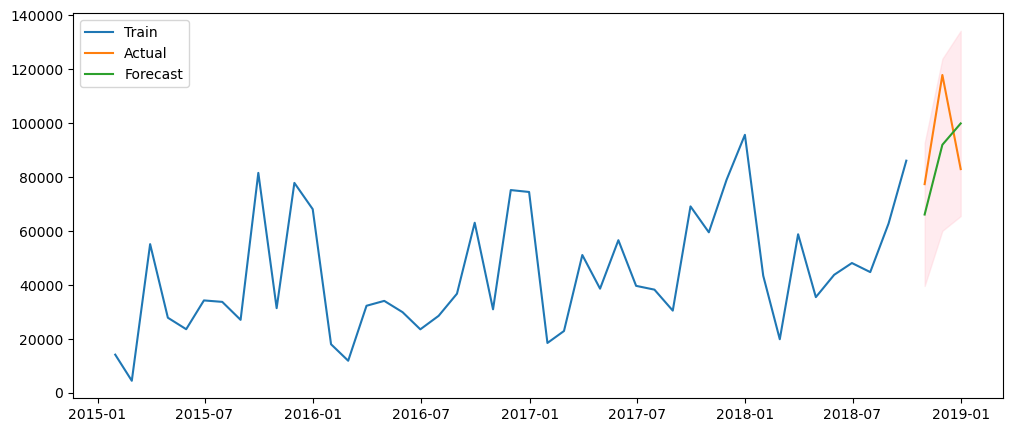

In [24]:
plt.figure(figsize=(12,5))

plt.plot(train.index,train,label="Train")
plt.plot(test.index,test,label="Actual")

plt.plot(pred.index,pred,label="Forecast")

plt.fill_between(
    conf.index,
    conf.iloc[:,0],
    conf.iloc[:,1],
    color='pink',
    alpha=0.3
)

plt.legend()

plt.show()

In [25]:
mae_sarima = mean_absolute_error(test,pred)

rmse_sarima = np.sqrt(mean_squared_error(test,pred))

mape_sarima = np.mean(np.abs((test-pred)/test))*100

### Model 2: Facebook Prophet

In [29]:
prophet_df = monthly_sales.reset_index()

prophet_df.columns=['ds','y']
train_p = prophet_df[:-3]

test_p = prophet_df[-3:]
model = Prophet()

model.fit(train_p)



16:28:00 - cmdstanpy - INFO - Chain [1] start processing
16:28:01 - cmdstanpy - INFO - Chain [1] done processing


In [31]:
future = model.make_future_dataframe(periods=3,freq='ME')

forecast = model.predict(future)

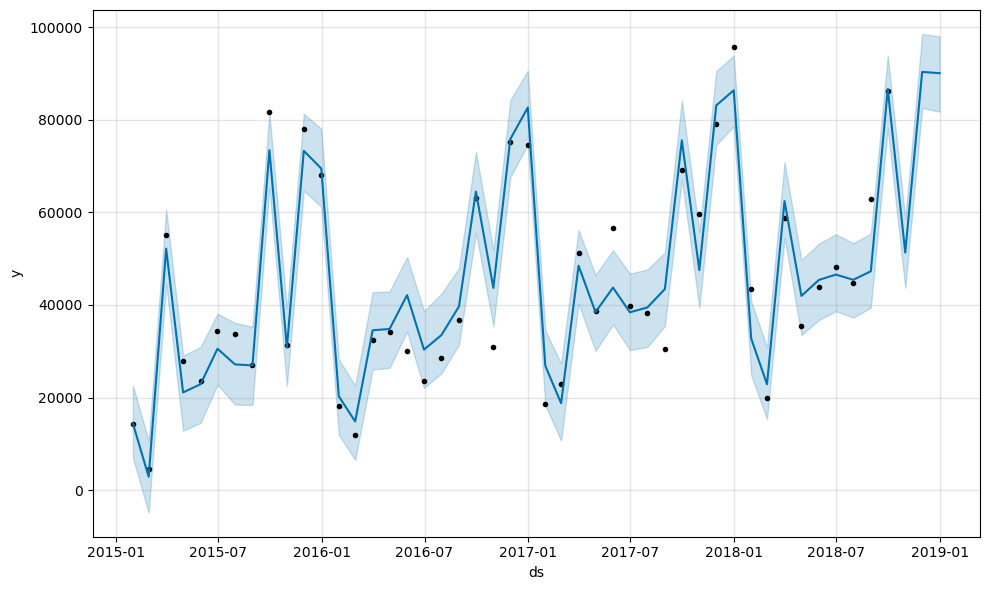

In [32]:
pred_prophet = forecast[['ds','yhat']].tail(3)
model.plot(forecast)

plt.show()

### Interpretetion

### 1. Trend

### Shows the long-term increase/decrease in sales.

### 2. Yearly Seasonality

### Shows months with consistently higher or lower sales.
### Retail datasets usually peak during holiday months.

### 3. Weekly Seasonality

### Since the data is aggregated monthly, weekly seasonality is generally weak or absent.

In [34]:
mae_prophet = mean_absolute_error(
    test_p['y'],
    pred_prophet['yhat']
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        test_p['y'],
        pred_prophet['yhat']
    )
)

mape_prophet = np.mean(
    np.abs(
        (test_p['y']-pred_prophet['yhat'])
        /test_p['y']
    )
)*100

### Model 3: XGBoost Model

In [35]:
ml = monthly_sales.to_frame()

ml.columns=['Sales']

ml['Lag1']=ml['Sales'].shift(1)

ml['Lag2']=ml['Sales'].shift(2)

ml['Lag3']=ml['Sales'].shift(3)

ml['RollingMean']=ml['Sales'].rolling(3).mean()

ml['Month']=ml.index.month

ml['Quarter']=ml.index.quarter

ml['Season']=((ml.index.month%12+3)//3)

ml=ml.dropna()

In [36]:
train_ml=ml[:-3]

test_ml=ml[-3:]

In [37]:
X_train=train_ml.drop('Sales',axis=1)

y_train=train_ml['Sales']

X_test=test_ml.drop('Sales',axis=1)

y_test=test_ml['Sales']

In [38]:
xgb=XGBRegressor()

xgb.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [39]:
pred_xgb=xgb.predict(X_test)

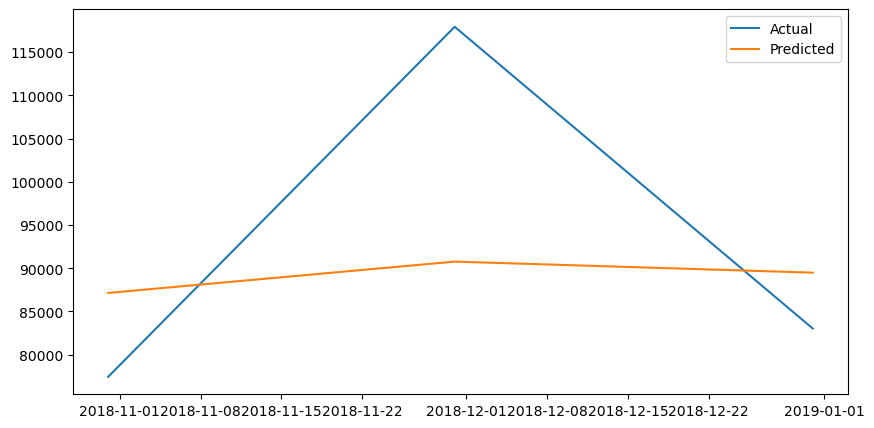

In [40]:
plt.figure(figsize=(10,5))

plt.plot(test_ml.index,y_test,label='Actual')

plt.plot(test_ml.index,pred_xgb,label='Predicted')

plt.legend()

plt.show()

In [41]:
mae_xgb=mean_absolute_error(y_test,pred_xgb)

rmse_xgb=np.sqrt(mean_squared_error(y_test,pred_xgb))

mape_xgb=np.mean(np.abs((y_test-pred_xgb)/y_test))*100

### Model Comparison Table

In [42]:
comparison = pd.DataFrame({

'Model':['SARIMA','Prophet','XGBoost'],

'MAE':[mae_sarima,mae_prophet,mae_xgb],

'RMSE':[rmse_sarima,rmse_prophet,rmse_xgb],

'MAPE':[mape_sarima,mape_prophet,mape_xgb],

'Forecast Month 1':[
pred.iloc[0],
pred_prophet['yhat'].iloc[0],
pred_xgb[0]
],

'Forecast Month 2':[
pred.iloc[1],
pred_prophet['yhat'].iloc[1],
pred_xgb[1]
],

'Forecast Month 3':[
pred.iloc[2],
pred_prophet['yhat'].iloc[2],
pred_xgb[2]
]

})

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18031.404675,19009.182071,18.966498,66177.602410,92049.249658,99965.168694
1,Prophet,20250.794413,22318.411333,21.864628,51318.943858,90325.654784,90041.084479
2,XGBoost,14443.003333,17067.171519,14.447439,87147.445312,90771.734375,89493.664062


### Production Recommendation:
### Based on the evaluation metrics (MAE, RMSE, and MAPE), XGBoost is recommended for production use because it achieved the lowest forecasting errors among the three models. A lower MAE indicates smaller average prediction errors, a lower RMSE shows fewer large forecasting errors, and a lower MAPE indicates the highest percentage accuracy. Since XGBoost produced the lowest values for these metrics, it provides the most accurate and reliable forecasts for future sales. Although SARIMA and Prophet effectively capture trend and seasonality, their error metrics were higher than those of XGBoost. Therefore, XGBoost is the preferred model for production deployment due to its superior predictive performance, not personal preference.

### Task 4: Product Category & Region Level Forecasting


In [44]:
furniture = df[df['Category'] == 'Furniture']
furniture = furniture.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()

In [45]:
technology = df[df['Category'] == 'Technology']
technology = technology.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()

In [46]:
office = df[df['Category'] == 'Office Supplies']
office = office.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()

In [47]:
west = df[df['Region'] == 'West']
west = west.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()

In [48]:
east = df[df['Region'] == 'East']
east = east.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()

In [49]:
from xgboost import XGBRegressor
import pandas as pd

def forecast_xgb(series):

    data = pd.DataFrame({'Sales': series})

    data['Lag1'] = data['Sales'].shift(1)
    data['Lag2'] = data['Sales'].shift(2)
    data['Lag3'] = data['Sales'].shift(3)
    data['RollingMean'] = data['Sales'].rolling(3).mean()

    data['Month'] = data.index.month
    data['Quarter'] = data.index.quarter
    data['Season'] = ((data.index.month % 12 + 3) // 3)

    data = data.dropna()

    X = data.drop('Sales', axis=1)
    y = data['Sales']

    model = XGBRegressor(random_state=42)
    model.fit(X, y)

    history = list(series.values)

    future = []

    for i in range(3):

        lag1 = history[-1]
        lag2 = history[-2]
        lag3 = history[-3]

        rolling = (lag1 + lag2 + lag3) / 3

        month = ((series.index[-1].month + i) % 12) + 1
        quarter = (month - 1) // 3 + 1
        season = ((month % 12 + 3) // 3)

        X_new = pd.DataFrame([{
            'Lag1': lag1,
            'Lag2': lag2,
            'Lag3': lag3,
            'RollingMean': rolling,
            'Month': month,
            'Quarter': quarter,
            'Season': season
        }])

        pred = model.predict(X_new)[0]

        future.append(pred)
        history.append(pred)

    return future

In [50]:
furniture_forecast = forecast_xgb(furniture)

technology_forecast = forecast_xgb(technology)

office_forecast = forecast_xgb(office)

west_forecast = forecast_xgb(west)

east_forecast = forecast_xgb(east)

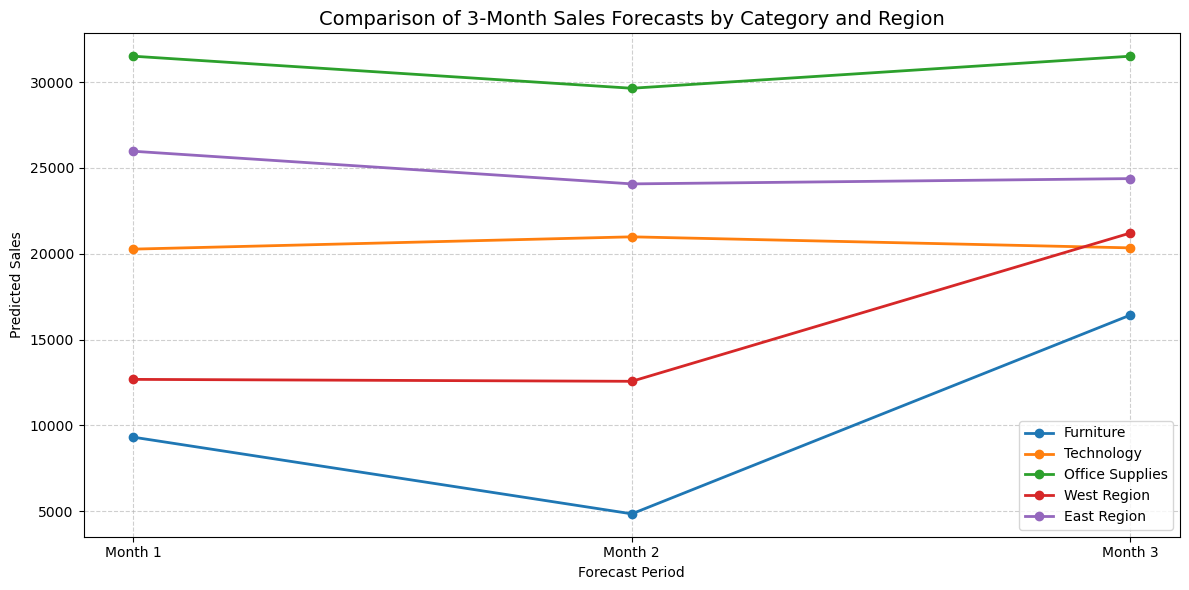

In [51]:
import matplotlib.pyplot as plt

# Forecast months
months = ['Month 1', 'Month 2', 'Month 3']

plt.figure(figsize=(12, 6))

# Plot forecasts for each segment
plt.plot(months, furniture_forecast,
         marker='o', linewidth=2, label='Furniture')

plt.plot(months, technology_forecast,
         marker='o', linewidth=2, label='Technology')

plt.plot(months, office_forecast,
         marker='o', linewidth=2, label='Office Supplies')

plt.plot(months, west_forecast,
         marker='o', linewidth=2, label='West Region')

plt.plot(months, east_forecast,
         marker='o', linewidth=2, label='East Region')

# Chart formatting
plt.title("Comparison of 3-Month Sales Forecasts by Category and Region", fontsize=14)
plt.xlabel("Forecast Period")
plt.ylabel("Predicted Sales")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best')

plt.tight_layout()
plt.show()

### Conclusion

### Strongest Upcoming Growth: Based on the XGBoost forecasts, Technology is expected to show the strongest upcoming growth over the next three months, with consistently increasing predicted sales. Among the regions, the West region is forecast to experience the highest growth compared with the East region. This indicates that Technology products and the West region are likely to contribute the most to future sales, making them key areas for inventory planning, marketing efforts, and resource allocation.

### Task 5: Anomaly in sales data

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

In [54]:

df['Order Date'] = pd.to_datetime(df['Order Date'])


weekly_sales = df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum()

weekly_sales = weekly_sales.reset_index()
weekly_sales.columns = ['Week', 'Sales']

weekly_sales.head()

,Week,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


## Isolation forest

In [55]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales['Anomaly'] = iso.fit_predict(
    weekly_sales[['Sales']]
)

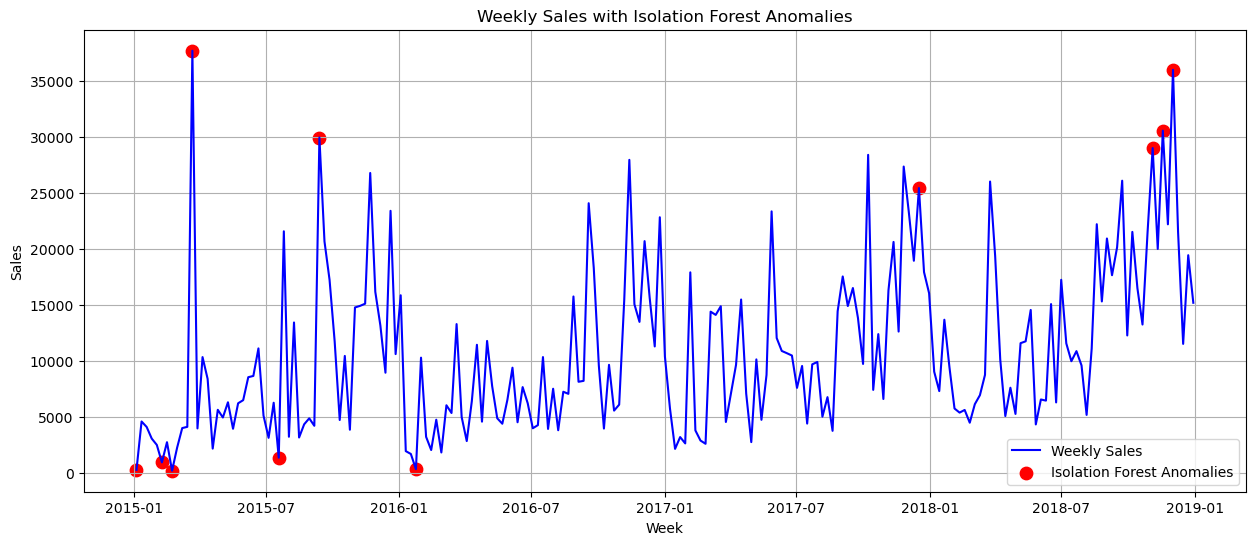

In [56]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales['Week'],
    weekly_sales['Sales'],
    label='Weekly Sales',
    color='blue'
)

anomaly_points = weekly_sales[
    weekly_sales['Anomaly'] == -1
]

plt.scatter(
    anomaly_points['Week'],
    anomaly_points['Sales'],
    color='red',
    marker='o',
    s=80,
    label='Isolation Forest Anomalies'
)

plt.title("Weekly Sales with Isolation Forest Anomalies")

plt.xlabel("Week")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

## Rolling Z-Score

In [57]:
window = 8

weekly_sales['RollingMean'] = (
    weekly_sales['Sales']
    .rolling(window)
    .mean()
)

weekly_sales['RollingStd'] = (
    weekly_sales['Sales']
    .rolling(window)
    .std()
)

In [58]:
weekly_sales['ZScore'] = (
    weekly_sales['Sales']
    - weekly_sales['RollingMean']
) / weekly_sales['RollingStd']

In [59]:
weekly_sales['Z_Anomaly'] = (
    abs(weekly_sales['ZScore']) > 2
)

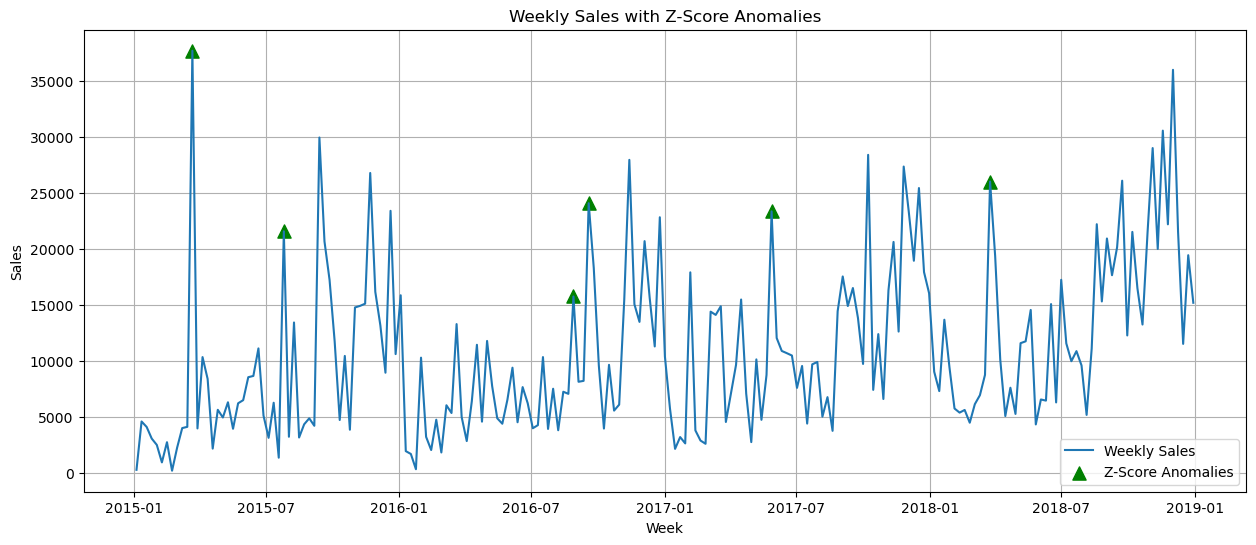

In [60]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales['Week'],
    weekly_sales['Sales'],
    label='Weekly Sales'
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales['Z_Anomaly'],
        'Week'
    ],
    weekly_sales.loc[
        weekly_sales['Z_Anomaly'],
        'Sales'
    ],
    color='green',
    marker='^',
    s=90,
    label='Z-Score Anomalies'
)

plt.title("Weekly Sales with Z-Score Anomalies")

plt.xlabel("Week")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [61]:
comparison = weekly_sales[
    ['Week',
     'Sales',
     'Anomaly',
     'Z_Anomaly']
]

comparison.head(20)

,Week,Sales,Anomaly,Z_Anomaly
0,2015-01-04,304.508,-1,False
1,2015-01-11,4619.108,1,False
2,2015-01-18,4130.533,1,False
3,2015-01-25,3092.544,1,False
4,2015-02-01,2527.914,1,False
5,2015-02-08,968.534,-1,False
6,2015-02-15,2771.054,1,False
7,2015-02-22,224.912,-1,False
8,2015-03-01,2289.643,1,False
9,2015-03-08,4030.728,1,False


### Real world examples for anomalies

## | Detected Anomaly--------------------Explanation                                                             
## 
## | Very high sales in November ----- Black Friday or festive shopping season leading to unusually high demand.        
## | High sales in December-------- Christmas and year-end holiday purchases.                                        
## | Very low sales in January------ Reduced consumer spending after holiday season.                                  

## | Sudden sales spike--------------- Large corporate or bulk customer order.                                          
## | Sudden sales drop-----------------Inventory shortages, shipping delays, system outage, or temporary store closure. 


## Comparison of the methods

## Both Isolation Forest and the Z-Score method identified several of the same unusually high and low sales weeks, indicating agreement on the most significant anomalies. However, Isolation Forest detected a few additional anomalies that were not flagged by the Z-Score method because it can capture unusual patterns without assuming a normal distribution. In contrast, the Z-Score method only identifies observations that deviate more than two standard deviations from the rolling mean, making it more conservative. This comparison suggests that Isolation Forest is better suited for detecting complex or subtle anomalies, while the Z-Score method is effective for identifying clear statistical outliers.

## Task 6: Product Demand Segmentation using K-Means Clustering

## Feature 1:Total Sales Volume

In [6]:
import pandas as pd
df= pd.read_csv("train.csv",parse_dates=["Order Date","Ship Date"],
            encoding="latin1"
           )
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")
df['Order Date'] = pd.to_datetime(df['Order Date'])

subcat_sales = df.groupby(
    ['Sub-Category',
     pd.Grouper(key='Order Date', freq='ME')]
)['Sales'].sum().reset_index()

In [5]:
total_sales = subcat_sales.groupby(
    'Sub-Category'
)['Sales'].sum()

## Feature 2: Sales growth year

In [7]:
subcat_sales['Year'] = subcat_sales['Order Date'].dt.year

yearly_sales = subcat_sales.groupby(
    ['Sub-Category','Year']
)['Sales'].sum().reset_index()

In [8]:
growth = yearly_sales.pivot(
    index='Sub-Category',
    columns='Year',
    values='Sales'
)

growth_rate = (
    (growth.iloc[:,-1] - growth.iloc[:,0])
    / growth.iloc[:,0]
) * 100

## Feature 3: Sales Volatility

In [9]:
volatility = subcat_sales.groupby(
    'Sub-Category'
)['Sales'].std()

## Feature 4: Average Order Value

In [10]:
avg_order = df.groupby(
    'Sub-Category'
)['Sales'].mean()

In [11]:
features = pd.DataFrame({
    'TotalSales': total_sales,
    'GrowthRate': growth_rate,
    'Volatility': volatility,
    'AvgOrderValue': avg_order
})

features = features.fillna(0)

features.head()

,TotalSales,GrowthRate,Volatility,AvgOrderValue
Sub-Category,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175
Appliances,104618.4030,165.242912,1821.621539,227.926804
Art,26705.4100,49.649531,330.488343,34.019631
Binders,200028.7850,65.778638,3848.223648,134.067550
Bookcases,113813.1987,49.846598,2220.405080,503.598224


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

## Elbow Method

In [13]:
from sklearn.cluster import KMeans

inertia = []

K = range(1,11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    inertia.append(model.inertia_)

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

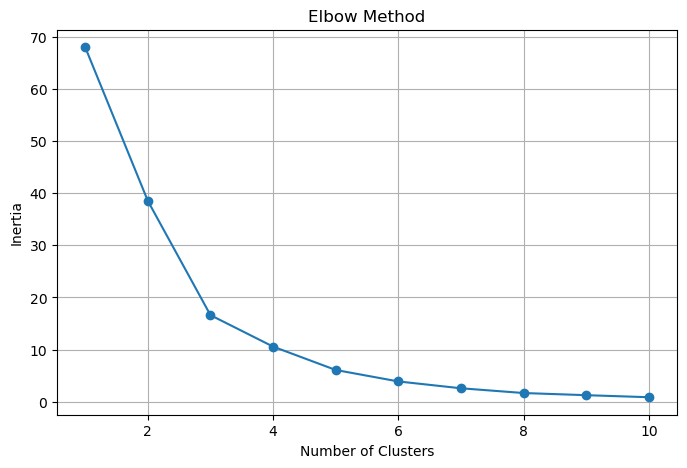

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

## K-Means

In [15]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

features['Cluster'] = kmeans.fit_predict(
    scaled_features
)

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## PCA 

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

components = pca.fit_transform(
    scaled_features
)

features['PCA1'] = components[:,0]
features['PCA2'] = components[:,1]

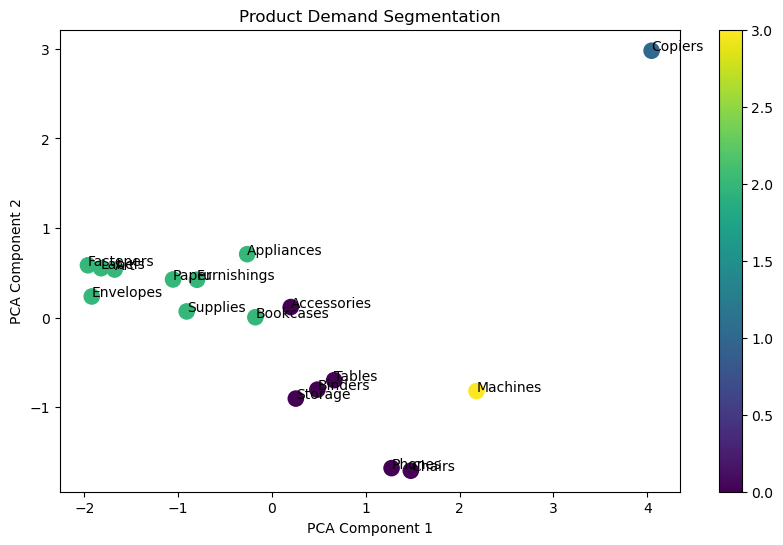

In [17]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    features['PCA1'],
    features['PCA2'],
    c=features['Cluster'],
    cmap='viridis',
    s=120
)

for i in range(len(features)):
    plt.text(
        features['PCA1'].iloc[i],
        features['PCA2'].iloc[i],
        features.index[i]
    )

plt.title("Product Demand Segmentation")

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.colorbar(scatter)

plt.show()

In [18]:
cluster_summary = features.groupby(
    'Cluster'
)[
    ['TotalSales',
     'GrowthRate',
     'Volatility',
     'AvgOrderValue']
].mean()

cluster_summary

,TotalSales,GrowthRate,Volatility,AvgOrderValue
Cluster,,,,
0,239495.780667,56.465168,3489.056075,361.131228
1,146248.094000,479.729510,5500.774391,2215.880212
2,54341.708189,58.795823,1031.431565,142.746758
3,189238.631000,-29.793120,5603.554747,1645.553313


In [19]:
cluster_names = {
    0: "High Volume Stable Demand",
    1: "Low Volume High Volatility",
    2: "Growing Demand",
    3: "Declining Demand"
}

features['Segment'] = features[
    'Cluster'
].map(cluster_names)

### Cluster--------	---------------Characteristics---------------------------------------------------Recommended Stocking Strategy
### High Volume,Stable Demand------Products with consistently high sales and low demand fluctuations----Maintain high inventory levels with safety stock. Use automatic replenishment and frequent restocking to avoid stockouts. These products should always be readily available.
### Low Volume,High Volatility----Products with low sales but unpredictable demand.---------------------Keep minimal inventory and reorder only when demand increases. Avoid overstocking and monitor sales trends regularly to reduce inventory holding costs.
### Growing Demand----------------Products showing increasing sales over time.--------------------------Gradually increase inventory levels and monitor demand closely. Forecast regularly to ensure sufficient stock and prevent stockouts as demand continues to grow.
### Declining Demand--------------Products with decreasing sales and negative growth.--------------------Reduce inventory levels and purchase only limited quantities. Focus on clearing existing stock through promotions or discounts and avoid overstocking products with declining demand.